In [7]:
%matplotlib inline

In [8]:
import os
from pathlib import Path

import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rc('figure', figsize=(6, 4.5))
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

import xarray as xr

from scipy.special import erf
from numpy import pi as π

In [9]:
# trig functions that take degrees

def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

# Make input directory

In [4]:
Path('./INPUT').mkdir(exist_ok=True)

# Create grid

In [13]:
grid = 'isotropic'

a = 6370e3
xw = 0
xe = 30
ys = 10
dx = 0.5

xq = np.arange(xw, xe+dx, dx)
xh = np.arange(xw+dx/2, xe, dx)

NX = len(xh)

if grid == 'latlon':
    yn = 45

    dy = 0.5

    yq = np.arange(ys, yn+dy, dy)
    yh = np.arange(ys+dy/2, yn, dy)
    NY = len(yh)
elif grid == 'isotropic': # aka Mercator
    NY = 81
    
    jh = np.arange(NY) + .5
    jq = np.arange(NY+1)

    yq = np.rad2deg(2*np.arctan(np.exp(jq*np.deg2rad(dx))*np.tan(π/4 + np.deg2rad(ys)/2)) - π/2)
    yh = np.rad2deg(2*np.arctan(np.exp(jh*np.deg2rad(dx))*np.tan(π/4 + np.deg2rad(ys)/2)) - π/2)
else:
    RuntimeError('unknown grid type')
    
    
dyq = a*np.deg2rad(np.diff(yh))
dyh = a*np.deg2rad(np.diff(yq))
dxq = a*np.deg2rad(dx)*cosd(yq)
dxh = a*np.deg2rad(dx)*cosd(yh)

Aq = dxq[1:-1]*dyq

# Layer configuration

In [11]:
Ω = 7.29e-5
f = 2*Ω*sind(30)

H = 4000
H1 = 443
H2 = H - H1
gp = 0.01
Hbar = H1*H2/H
np.sqrt(gp*Hbar)/f/1e3

27.226152434144517

In [7]:
# number of layers
NK = 2

# maximum depth

# interface depths
eta = np.array([
       0,
    -443, # this comes from the Parsons-Veronis calculation in Parsons-Veronis.ipynb
  -12000, # the last entry can be anything as long as it's deeper than the basin
], dtype=float) 

interface_IC = xr.Dataset(
    {'eta': (['nki'], eta, {'long_name': 'Initial depth of interfaces', 'units': 'meters'})},
)

interface_IC.to_netcdf('INPUT/interface_IC.nc')

In [8]:
interface_IC

<xarray.Dataset>
Dimensions:  (nki: 3)
Dimensions without coordinates: nki
Data variables:
    eta      (nki) float64 0.0 -443.0 -1.2e+04

# Wind forcing

The wind forcing is the same as in the Parsons-Veronis notebook.

In [14]:
T0 = 20e6
ρ0 = 1035 # Boussinesq reference density
Ω = 7.29e-5
a = 6370e3

lonE = 30 # eastern boundary
λe = np.deg2rad(lonE)

V0 = T0/(a*λe*cosd(25))

def tau(θ, derivative=False):
    if derivative:
        return -(V0*Ω/(1386*np.cos(θ)**2))*np.piecewise(θ, 
                    [θ > np.deg2rad(15), θ <= np.deg2rad(15)],
                    [lambda θ: 315*np.sin(12*θ + π/4) + 994*np.sin(10*θ + π/4) + 1067*np.sin(8*θ + π/4) + 396*np.sin(6*θ + π/4) + 36*np.sin(θ), 
                     lambda θ: (190 + 81*np.sqrt(3))*np.sin(θ)])
    else:
        return (V0*Ω/(1386*np.cos(θ)))*np.piecewise(θ, 
                    [θ > np.deg2rad(15), θ <= np.deg2rad(15)],
                    [lambda θ: 63*np.cos(11*θ + π/4) + 154*np.cos(9*θ + π/4) + 99*np.cos(7*θ + π/4) - 36, 
                     lambda θ: -190 - 81*np.sqrt(3) ])


taux = ρ0*np.repeat(tau(np.deg2rad(yh))[:,np.newaxis], NX+1, axis=1)
tauy = np.zeros((NY+1, NX))



In [43]:
V0

6.616315851855421

In [36]:
f = 2*Ω*sind(yh)
fq = 2*Ω*sind(yq)
β = 2*Ω*cosd(yh)/a
βq = 2*Ω*cosd(yq)/a
Lxh = a*np.deg2rad(xe-xw)*cosd(yh)
Lxq = a*np.deg2rad(xe-xw)*cosd(yq)


# net Ekman transport
Vek = -tau(np.deg2rad(yh))/f

# Sverdrup transport
wsc = -np.diff(dxh*tau(np.deg2rad(yh)))/Aq
Vsv = (1/βq)[1:-1]*wsc

# net geostrophic transport
wEk = -np.diff(dxh*tau(np.deg2rad(yh))/f)/Aq
Vg = (1*fq/βq)[1:-1]*wEk

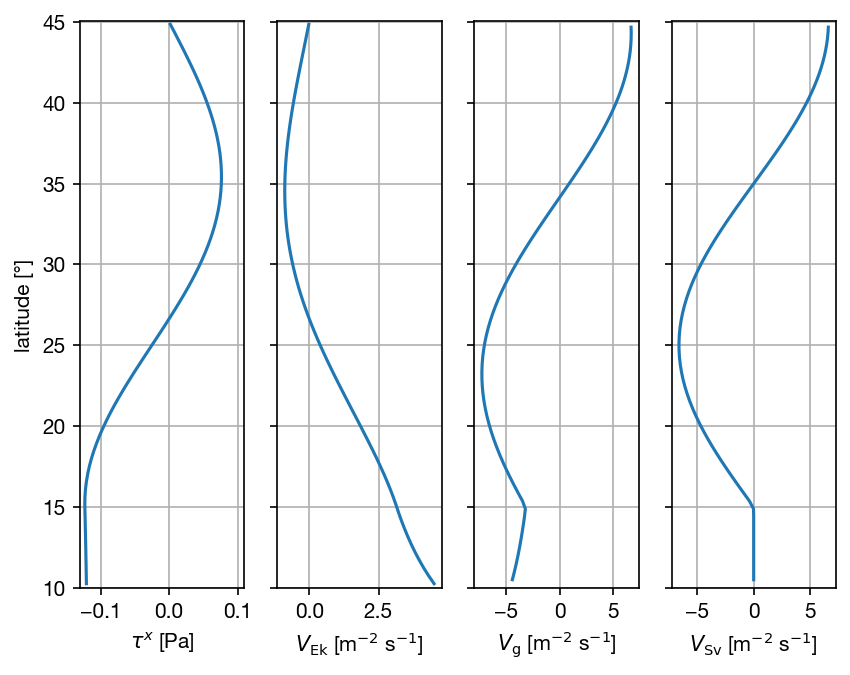

In [42]:
fig, axs = plt.subplots(ncols=4, sharey=True, figsize=(6.5, 5))

ax = axs[0]
ax.plot(taux[:,0], yh)
ax.set_xlim(-.13, .11)
ax.set_xlabel(r'$\tau^x$ [Pa]')
ax.set_ylabel('latitude [\N{DEGREE SIGN}]')

ax = axs[1]
ax.plot(Vek, yh)
ax.set_xlabel(r'$V_\mathrm{Ek}$ [m$^{-2}$ s$^{-1}$]')

ax = axs[2]
ax.plot(Vg, yq[1:-1], '-')
# ax.set_xlim([-24, 24])
ax.set_xlabel(r'$V_\mathrm{g}$ [m$^{-2}$ s$^{-1}$]')

ax = axs[3]
ax.plot(Vsv, yq[1:-1])
# ax.set_xlim([-24, 24])
ax.set_xlabel(r'$V_\mathrm{Sv}$ [m$^{-2}$ s$^{-1}$]')

ax.set_ylim([yq[0], yq[-1]])

for ax in axs:
#     ax.axhline(33.5, ls='--', color='k')
    ax.grid()

fig.savefig('wind_forcing.pdf', bbox_inches='tight')
fig.savefig('wind_forcing.png', bbox_inches='tight', dpi=150)


In [29]:
axs[2].get_xlim()

(-24.145224206163206, 17.90239638512104)

In [30]:
# MOM6 expects xq and yq to have be missing the last point
forcing = xr.Dataset(coords={
    'yh': (['yh'], yh), 
    'xh': (['xh'], xh),
    'yq': (['yq'], yq[:-1]), 
    'xq': (['xq'], xq[:-1]),
})

forcing['STRESS_X'] = (['yh', 'xq'], taux[:,:-1], {'long_name': 'Zonal Momentum Flux', 'units': 'Pa'})
forcing['STRESS_Y'] = (['yq', 'xh'], tauy[:-1,:], {'long_name': 'Meridional Momentum Flux', 'units': 'Pa'})

forcing.to_netcdf('INPUT/forcing.nc')

forcing

<xarray.Dataset>
Dimensions:   (yh: 81, xh: 60, yq: 81, xq: 60)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
Data variables:
    STRESS_X  (yh, xq) float64 -0.1209 -0.1209 -0.1209 ... 0.001726 0.001726
    STRESS_Y  (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

Read back in after running the model to make sure it took

In [21]:
ds = xr.open_dataset('forcing__0001_003.nc')
forcing_diag = ds
ds.close()

<xarray.Dataset>
Dimensions:     (Time: 2, nv: 2, xq: 61, yh: 100)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.75 11.25 11.75 ... 58.25 58.75 59.25 59.75
  * Time        (Time) object 0001-01-03 12:00:00 0001-01-08 12:00:00
  * nv          (nv) float64 1.0 2.0
Data variables:
    taux        (Time, yh, xq) float32 ...
    average_T1  (Time) object ...
    average_T2  (Time) object ...
    average_DT  (Time) timedelta64[ns] ...
    Time_bnds   (Time, nv) timedelta64[ns] ...
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

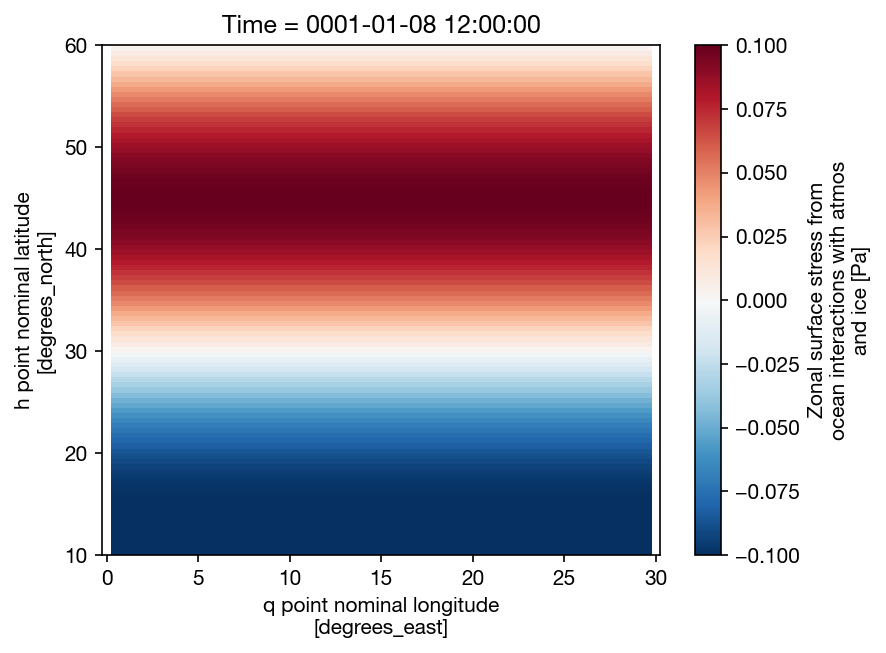

In [23]:
forcing_diag.taux.isel(Time=-1).plot()